<a href="https://colab.research.google.com/github/sing7726/Business-Data-Analysis/blob/main/uber_data_analysis_by_HarnoorSingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uber Data Analysis Project

## Objective

In this project, Uber trip data is analyzed for April 2023. The main objective of this project is to understand how Uber trip demand changes by hour, day, and weekday.

The project starts by loading the dataset and checking its structure. After that, the `Date/Time` column is cleaned and converted into a proper datetime format. New columns such as hour, day, weekday, and weekday name are created to make time-based analysis easier.

Finally, visualizations are created to identify busy and slow periods for Uber trips. The analysis is also used to provide a simple business recommendation based on demand patterns.

## Dataset

The dataset contains Uber trip records from April 2014. The main columns are:

- `Date/Time`: date and time of the trip
- `Lat`: latitude of the trip location
- `Lon`: longitude of the trip location
- `Base`: Uber base code


## 1. Import Libraries and Load Dataset

In this step, the required Python libraries are imported. Pandas is used to work with the dataset, NumPy is used for numerical operations, and Matplotlib is used for creating graphs.

The dataset is then loaded from an online CSV file into a Pandas DataFrame. A DataFrame is like a table in Python, similar to an Excel sheet.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
url = "https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-apr14.csv"
df = pd.read_csv(url)

# View first 5 rows
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


## 2. Explore the Dataset

In this step, the dataset is checked to understand the number of rows, number of columns, data types, and basic statistics.

This helps to understand whether any column needs cleaning or conversion before analysis.

In [2]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [3]:
# Check basic statistics for numerical columns
df.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


## 3. Data Cleaning and Feature Engineering

The `Date/Time` column is first converted into datetime format. This is important because Python needs to understand this column as actual time data, not just text.

After that, new columns are created from the `Date/Time` column:

- `hour`: hour of the day
- `day`: day of the month
- `weekday`: weekday number
- `weekday_name`: name of the weekday

These new columns help in finding patterns in Uber trip demand.

In [4]:
# Convert Date/Time column into datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Create new time-based columns
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday
df['weekday_name'] = df['Date/Time'].dt.day_name()

# Check updated dataset
df.head()

,Date/Time,Lat,Lon,Base,hour,day,weekday,weekday_name
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,1,Tuesday
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,1,Tuesday
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,1,Tuesday
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,1,Tuesday
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,1,Tuesday


## 4. Basic Time-Based Analysis

In this step, the number of Uber trips is counted by hour, day, and weekday. This helps to identify when Uber demand is high and when it is low.

In [6]:
# Count number of trips by hour
hour_counts = df['hour'].value_counts().sort_index()

# Count number of trips by day
day_counts = df['day'].value_counts().sort_index()

# Count number of trips by weekday in correct order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = df['weekday_name'].value_counts().reindex(weekday_order)

print("Trips by hour:")
print(hour_counts)

print("Trips by weekday:")
print(weekday_counts)

Trips by hour:
hour
0     11910
1      7769
2      4935
3      5040
4      6095
5      9476
6     18498
7     24924
8     22843
9     17939
10    17865
11    18774
12    19425
13    22603
14    27190
15    35324
16    42003
17    45475
18    43003
19    38923
20    36244
21    36964
22    30645
23    20649
Name: count, dtype: int64
Trips by weekday:
weekday_name
Monday        60861
Tuesday       91185
Wednesday    108631
Thursday      85067
Friday        90303
Saturday      77218
Sunday        51251
Name: count, dtype: int64


In [7]:
# Find busiest and slowest hour
busiest_hour = hour_counts.idxmax()
busiest_count = hour_counts.max()

slowest_hour = hour_counts.idxmin()
slowest_count = hour_counts.min()

print("Busiest hour:", busiest_hour, "with", busiest_count, "trips")
print("Slowest hour:", slowest_hour, "with", slowest_count, "trips")

Busiest hour: 17 with 45475 trips
Slowest hour: 2 with 4935 trips


In [8]:
# Top 5 busiest hours
top_hours = hour_counts.sort_values(ascending=False).head(5)

print("Top 5 busiest hours:")
print(top_hours)

Top 5 busiest hours:
hour
17    45475
18    43003
16    42003
19    38923
21    36964
Name: count, dtype: int64


In [9]:
# Convert hourly trip counts into percentage
hour_percentage = (hour_counts / hour_counts.sum()) * 100

print("Percentage of trips by hour:")
print(hour_percentage.round(2))

Percentage of trips by hour:
hour
0     2.11
1     1.38
2     0.87
3     0.89
4     1.08
5     1.68
6     3.28
7     4.42
8     4.05
9     3.18
10    3.16
11    3.33
12    3.44
13    4.00
14    4.82
15    6.26
16    7.44
17    8.06
18    7.62
19    6.89
20    6.42
21    6.55
22    5.43
23    3.66
Name: count, dtype: float64


## Observation

The dataset contains Uber trip records for April 2014. After converting the `Date/Time` column into datetime format, new columns such as hour, day, weekday, and weekday name were created.

These new columns make it easier to analyze trip demand over time. The busiest and slowest hours can now be identified using trip counts by hour.

## 5. Data Visualization

Visualizations are created to make the patterns in the data easier to understand. Instead of only looking at numbers, graphs help show when Uber trips are highest and lowest.

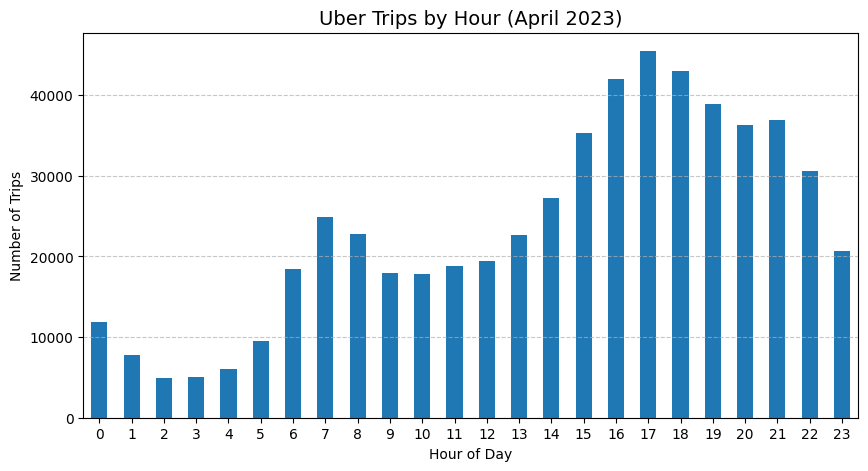

In [10]:
# Plot number of Uber trips by hour
plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar')

plt.title("Uber Trips by Hour (April 2014)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation from Hourly Trips

The graph shows that Uber trips are lower during early morning hours and increase as the day continues. The highest demand appears during the evening hours, especially around the time people finish work or go out.

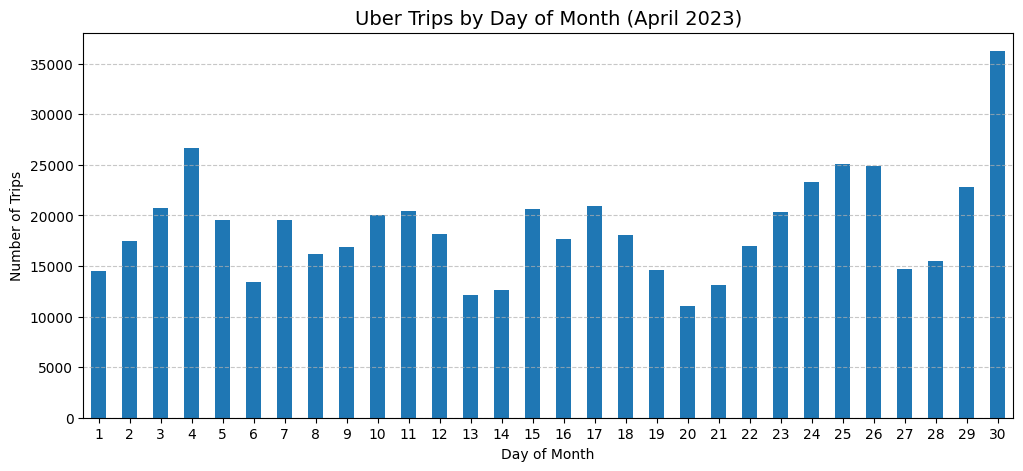

In [11]:
# Plot number of Uber trips by day of month
plt.figure(figsize=(12, 5))
day_counts.plot(kind='bar')

plt.title("Uber Trips by Day of Month (April 2014)", fontsize=14)
plt.xlabel("Day of Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation from Daily Trips

The daily trip graph helps to compare demand across different dates in April 2014. Some days have higher activity than others, which may be connected to weekdays, weekends, or general travel patterns.

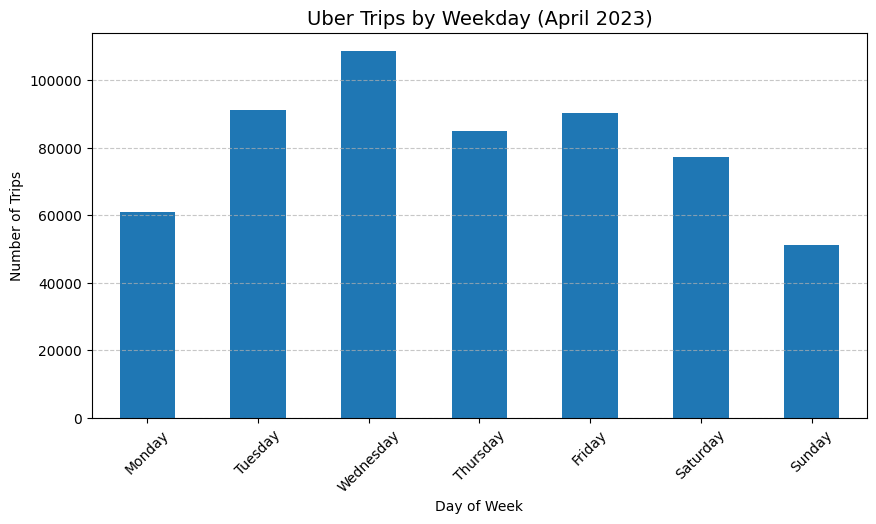

In [12]:
# Plot number of Uber trips by weekday
plt.figure(figsize=(10, 5))
weekday_counts.plot(kind='bar')

plt.title("Uber Trips by Weekday (April 2014)", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Observation from Weekday Trips

The weekday graph shows how trip demand changes across the week. This helps to compare ride activity on weekdays and weekends.

## 6. Advanced Visualization: Day and Hour Demand Pattern

This heatmap-style visualization shows how Uber trip demand changes by both weekday and hour. It gives a better view of when demand is highest during the week.

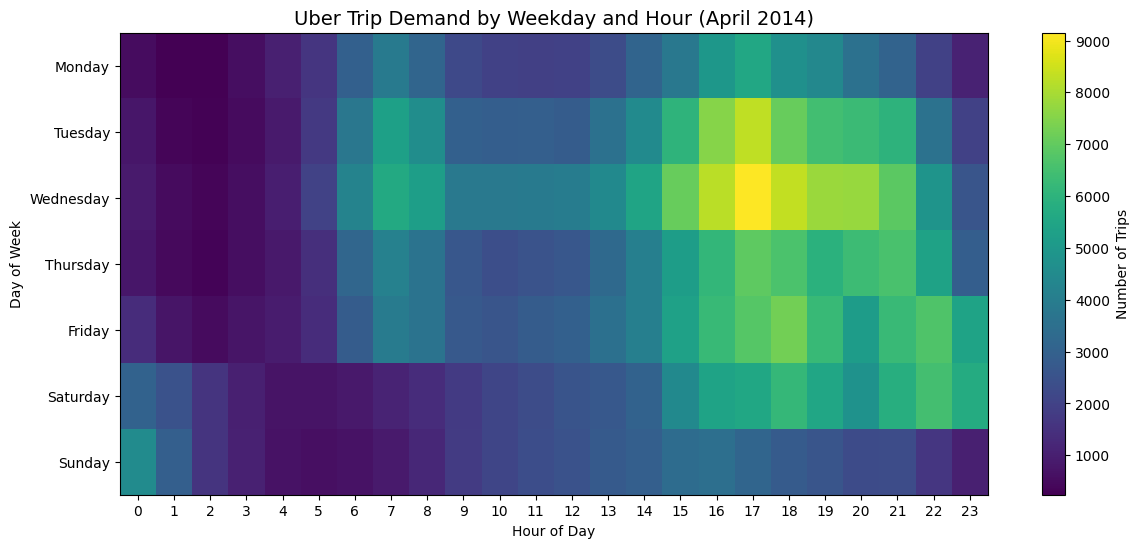

In [13]:
# Create a pivot table for weekday and hour
heatmap_data = df.pivot_table(index='weekday_name', columns='hour', values='Base', aggfunc='count')
heatmap_data = heatmap_data.reindex(weekday_order)

# Plot heatmap-style chart using Matplotlib
plt.figure(figsize=(14, 6))
plt.imshow(heatmap_data, aspect='auto')

plt.title("Uber Trip Demand by Weekday and Hour (April 2014)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)
plt.colorbar(label="Number of Trips")

plt.show()

## Key Insights

1. Uber trip demand is lowest during early morning hours, especially from around 2 AM to 5 AM.
2. Trip demand increases as the day continues and becomes much stronger in the afternoon and evening.
3. The highest number of trips occurs during evening hours, especially around 5 PM to 8 PM.
4. Weekday and weekend patterns show that demand is not the same every day.
5. The demand pattern suggests that Uber trips are influenced by work schedules, commuting time, and social activity periods.

## Business Recommendation

Based on the analysis, Uber can improve driver allocation by increasing driver availability during peak evening hours and reducing supply during low-demand early morning hours.

This can help reduce customer wait times, improve service availability during busy periods, and help drivers focus on the hours when demand is higher.

## Conclusion

This project shows how time-based analysis can be used to understand Uber trip demand. By cleaning the datetime column and creating new features such as hour, day, and weekday, clear patterns in ride demand can be identified.

The analysis shows that Uber demand is generally lower in the early morning and higher during evening hours. These insights can support better operational planning and driver availability decisions.

## Skills Demonstrated

This project demonstrates the following data analysis skills:

- Loading CSV data using Pandas
- Exploring dataset structure and summary statistics
- Cleaning and converting datetime data
- Feature engineering using time-based columns
- Grouping and counting data to find patterns
- Creating visualizations with Matplotlib
- Writing business insights from data